In [1]:
from alerce.core import Alerce
from astropy.table import vstack, Table
import matplotlib.pyplot as plt
import pyvo as vo
import requests
import sqlalchemy as sa
import sys
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import re
import george
import scipy.optimize as op
import emcee
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
alerce = Alerce()
alerce_tap = vo.dal.TAPService('https://tap.alerce.online/tap')

In [3]:
filename = "../Data/tns_Ia.csv"
sources = Table.read(filename, format="csv")
sources[0]

objid,name_prefix,name,ra,declination,redshift,typeid,type,reporting_groupid,reporting_group,source_groupid,source_group,discoverydate,discoverymag,discmagfilter,filter,reporters,time_received,internal_names,Discovery_ADS_bibcode,Class_ADS_bibcodes,creationdate,lastmodified
int64,str2,str8,float64,float64,float64,int64,str5,int64,str17,int64,str5,str23,float64,int64,str1,str454,str19,str146,str19,str61,str19,str19
207908,SN,2026lns,202.4570465,-5.7516547,0.0686,3,SN Ia,48,ZTF,48,ZTF,2026-05-07 05:03:27.996,19.2662,111,r,"Jesper Sollerman (SU), Christoffer Fremling (Caltech), Daniel Perley (LJMU), Theophile du Laz (Caltech) on behalf of ZTF",2026-05-07 09:15:10,"ZTF26aauvdne, GOTO26ejc, , ATLAS26fhx",2026TNSTR1975....1S,--,2026-05-07 09:15:12,2026-05-11 05:50:45


In [4]:
ZTF_mask = sources["source_group"] == "ZTF"
ZTF = sources[ZTF_mask]
ZTF[0]

objid,name_prefix,name,ra,declination,redshift,typeid,type,reporting_groupid,reporting_group,source_groupid,source_group,discoverydate,discoverymag,discmagfilter,filter,reporters,time_received,internal_names,Discovery_ADS_bibcode,Class_ADS_bibcodes,creationdate,lastmodified
int64,str2,str8,float64,float64,float64,int64,str5,int64,str17,int64,str5,str23,float64,int64,str1,str454,str19,str146,str19,str61,str19,str19
207908,SN,2026lns,202.4570465,-5.7516547,0.0686,3,SN Ia,48,ZTF,48,ZTF,2026-05-07 05:03:27.996,19.2662,111,r,"Jesper Sollerman (SU), Christoffer Fremling (Caltech), Daniel Perley (LJMU), Theophile du Laz (Caltech) on behalf of ZTF",2026-05-07 09:15:10,"ZTF26aauvdne, GOTO26ejc, , ATLAS26fhx",2026TNSTR1975....1S,--,2026-05-07 09:15:12,2026-05-11 05:50:45


In [5]:
#ZTF["internal_names"][0][:12]
ZTF_obj_Ia = []
pattern = r"ZTF"
for obj in ZTF["internal_names"]:
    #print(obj)
    if isinstance(obj, str):
        internal = obj.split(',')
        survay_name = [name for name in internal if re.search(pattern, name)]
        if survay_name:
            ZTF_obj_Ia.append(survay_name[0])

ZTF_obj_Ia = np.array(ZTF_obj_Ia)
print(len(ZTF_obj_Ia))

6425


In [6]:
max_curves = 20
light_curves = []
for obj in ZTF_obj_Ia[:max_curves]:
    light = alerce.query_forced_photometry(obj, format="json")
    light_curves.append(light)

18.173635482788086
16


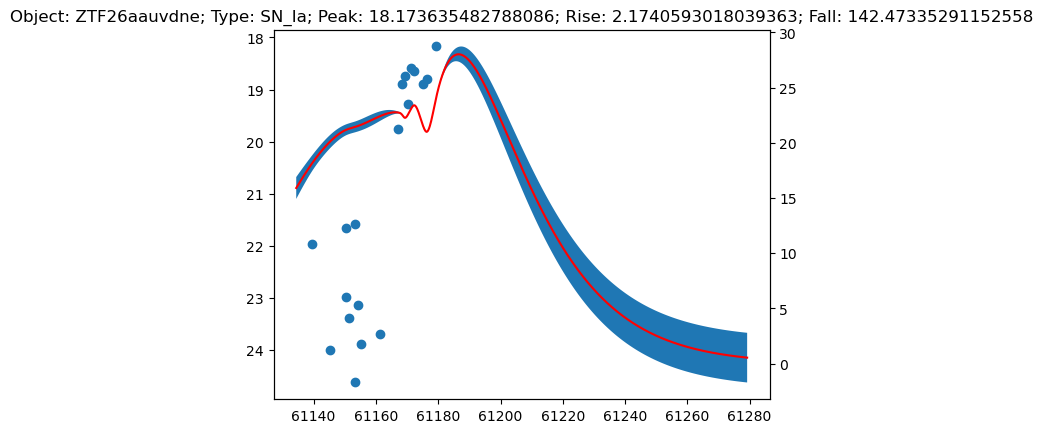

18.999319076538086
15


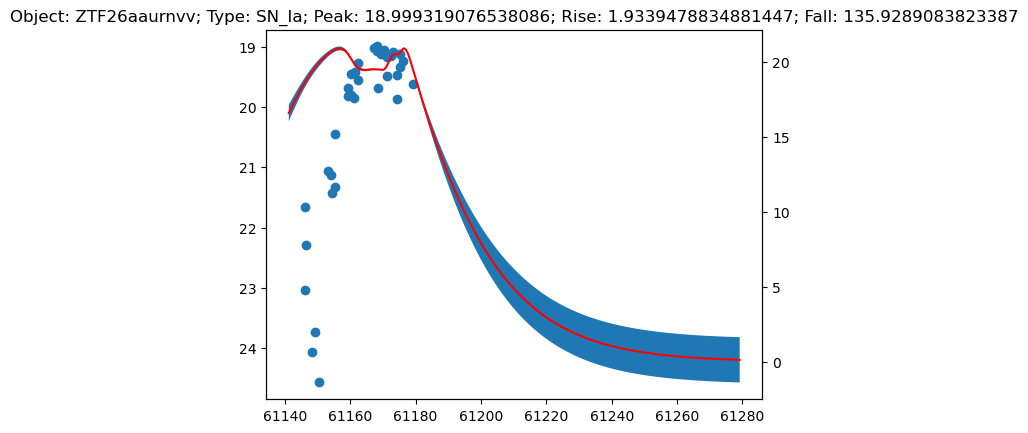

18.745914459228516
18


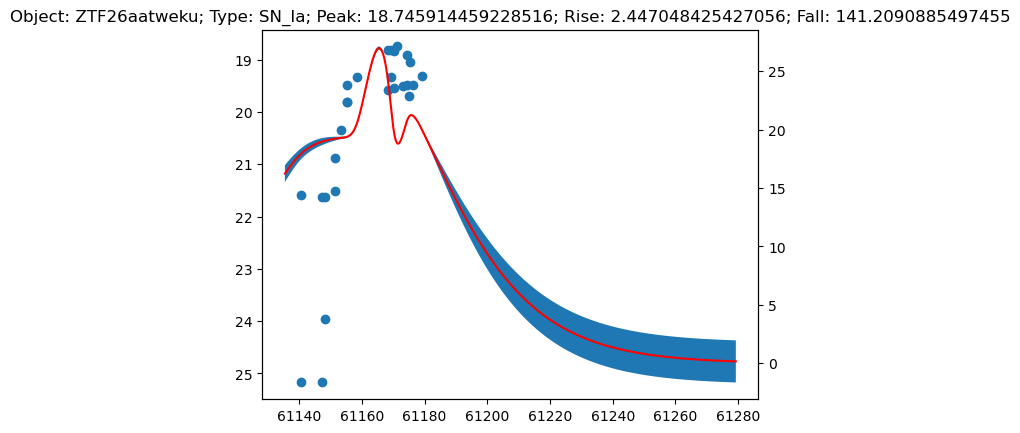

17.970325469970703
20


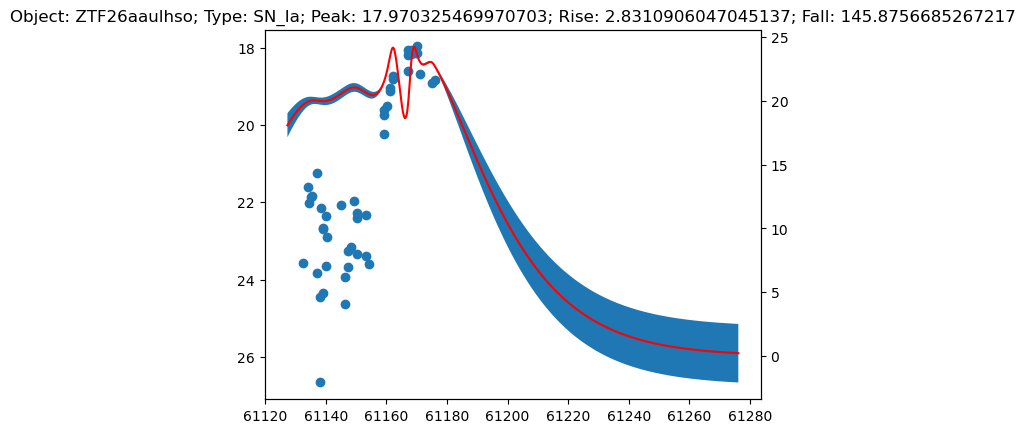

17.836261749267578
62


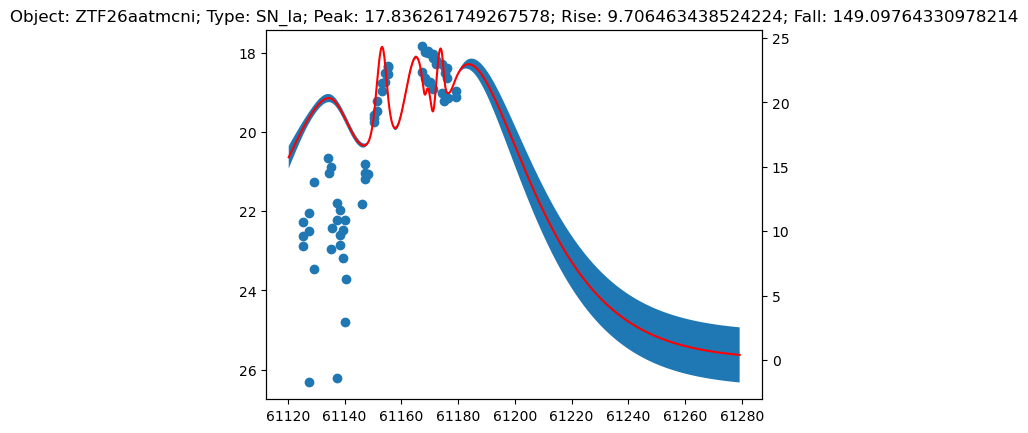

17.817792892456055
23


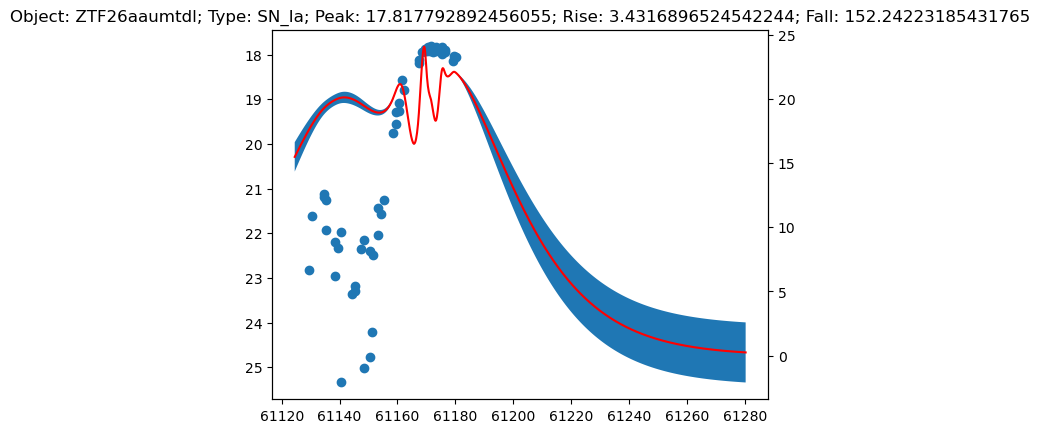

18.642131805419922
59


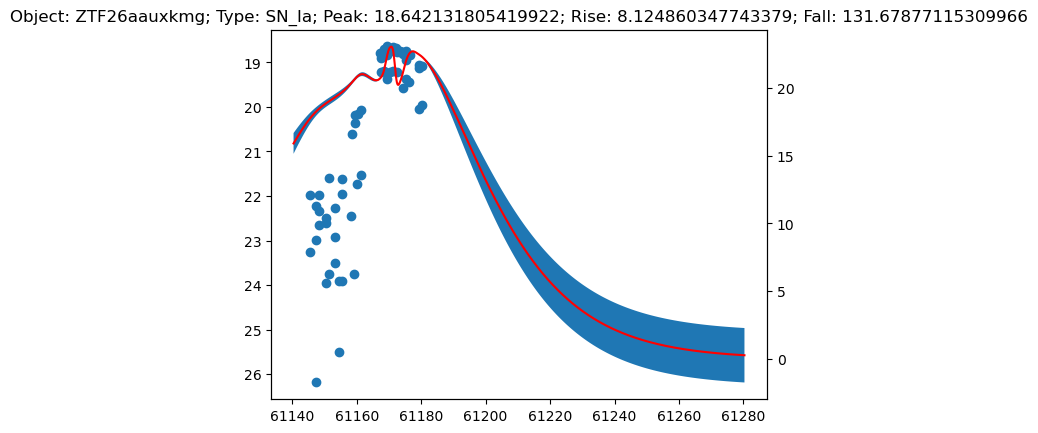

18.18297004699707
21


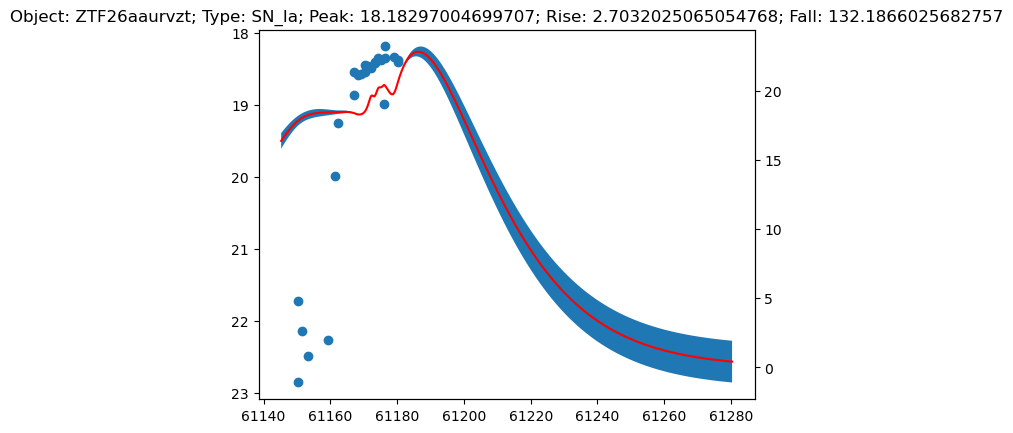

19.229652404785156
3


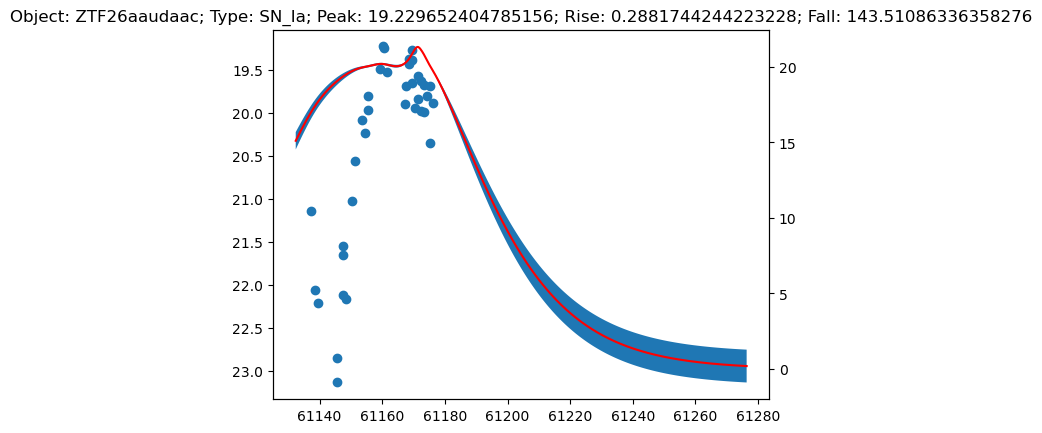

18.530515670776367
30


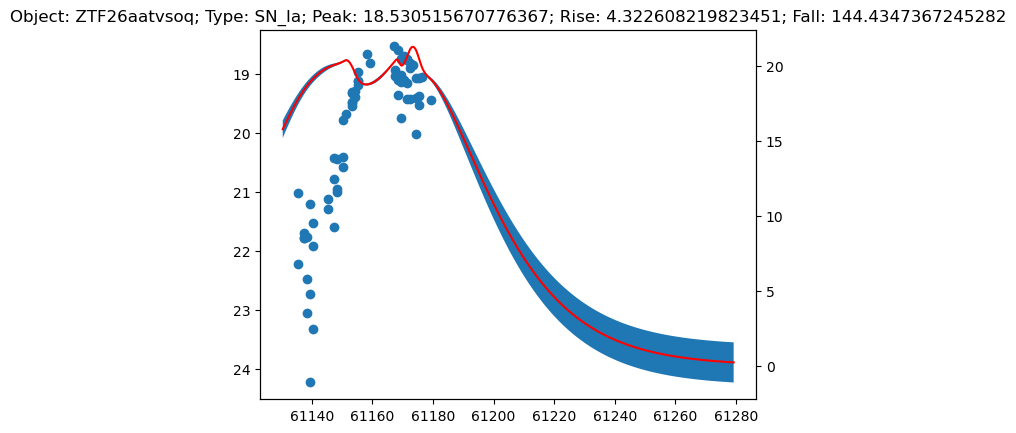

19.0690975189209
5


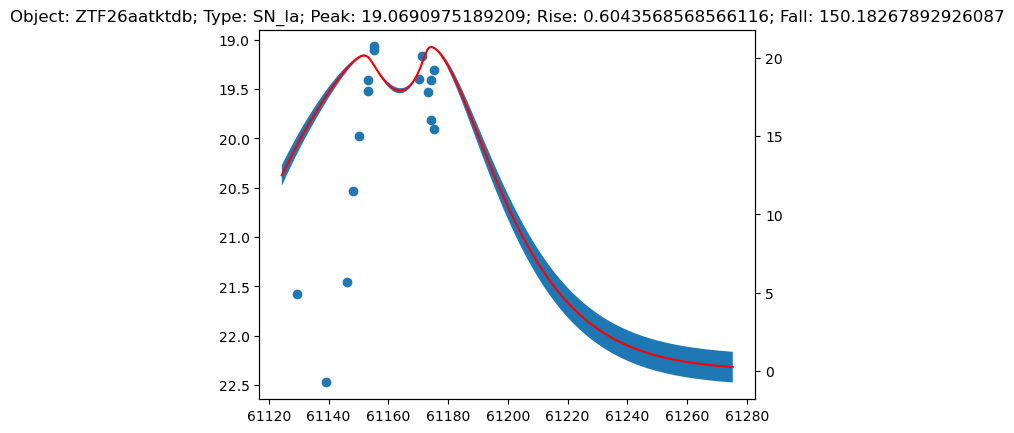

18.591636657714844
60


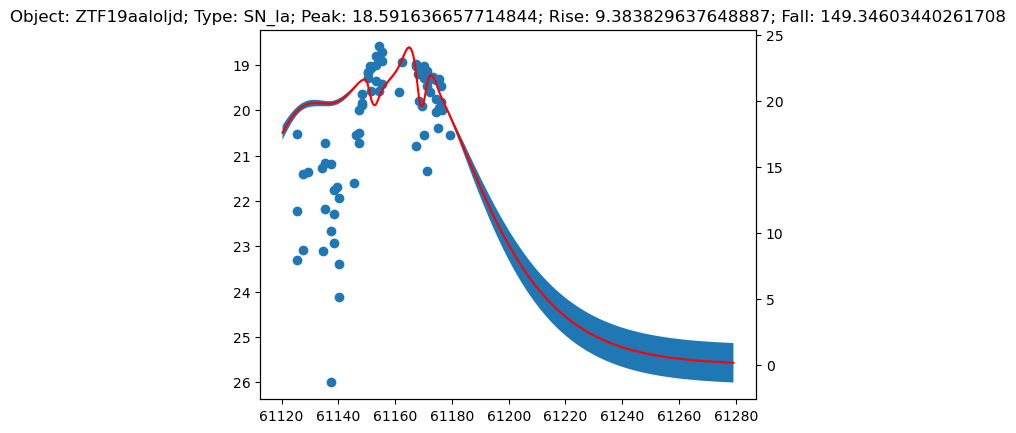

18.380491256713867
14


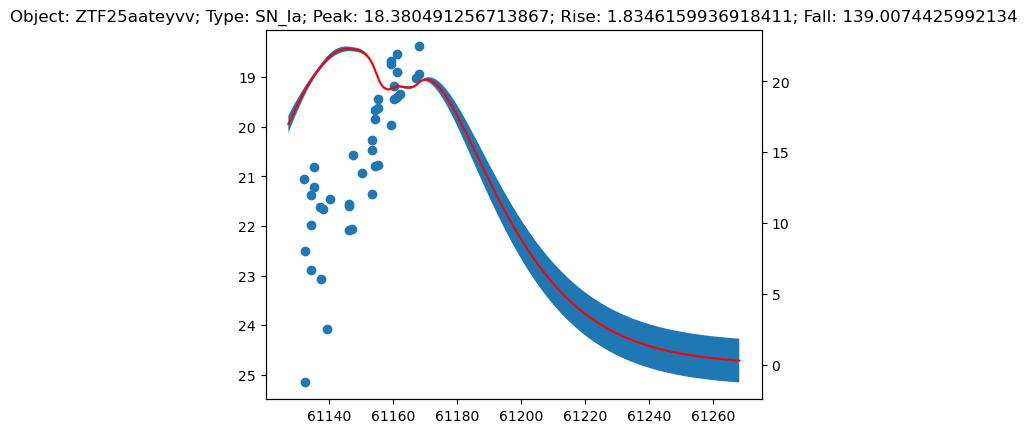

18.119901657104492
17


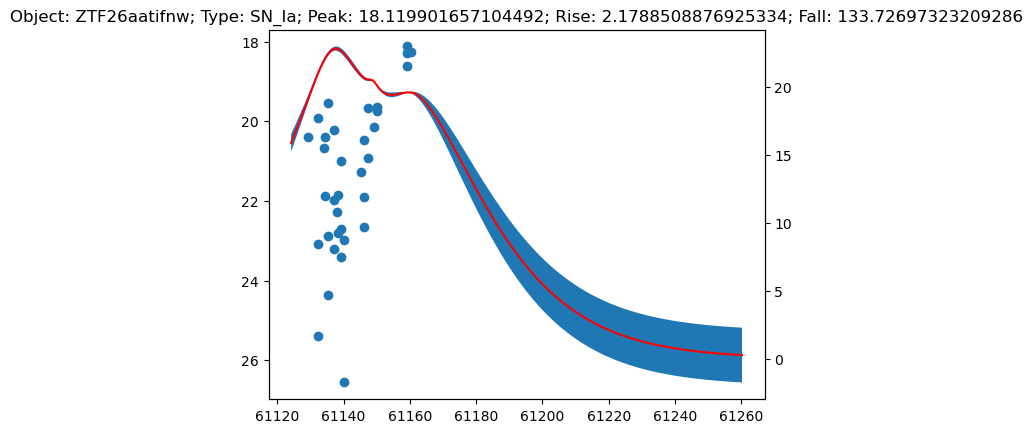

In [22]:
with PdfPages('./SN_Ia_plots.pdf') as pdf:
    dic_curves = []
    for light in light_curves:
    
        if len(light) > 10:
    
            #initialize data
            time = [obs["mjd"] for obs in light]
            mag = [obs["mag"] for obs in light]
            error = [obs["e_mag"] for obs in light]

            mag_flipped = np.flipud(mag)

            fig, ax1 = plt.subplots()
            
            #plot raw lightcurve
            ax1.scatter(time, mag, marker='o')
            ax1.invert_yaxis()
        
            #initialize data range
            x_fit = np.linspace(np.min(time) - 5, np.max(time) + 100, 1000)
        
            #get george off
            #kernel =  np.var(mag_flipped) * george.kernels.ExpSquaredKernel(80)
            kernel = np.var(mag_flipped) * george.kernels.Matern32Kernel(metric=750)
            gp = george.GP(kernel, solver=george.HODLRSolver)
            
            #use george
            gp.compute(time, error)
            #print(mag_flipped.shape, x_fit.shape)
            pred, pred_var = gp.predict(mag_flipped, x_fit, return_var=True)

            #find rise time
            peak = np.min(mag)
            print(peak)
            peak_index = np.argmin(mag)
            print(peak_index)
            slopes = np.gradient(pred, x_fit)
            rise_days = 0
            for point in x_fit[:peak_index]:
                if slopes[np.where(x_fit == point)] < 1:
                    rise_days = point
            rise_time = rise_days - x_fit[0]

            #find down time
            down_days = 0
            for point in x_fit[peak_index:]:
                if slopes[np.where(x_fit == point)] < 1:
                    down_days = point
            fall_time = down_days - x_fit[peak_index]

            #add curve to dictionary and append to list
            #print(table_curves)
            error = np.pow(pred_var, 0.5)
            dic = {"object": light[0]["oid"], "type": "SNIa", "mjd": x_fit, "mag": pred, "error": error, "peak": peak, "rise": rise_time, "fall": fall_time}
            dic_curves.append(dic)
            #print(table_curves)

            ax2 = ax1.twinx()

            #plot george
            ax2.plot(x_fit, pred, color='r')
        
            ax2.fill_between(x_fit, pred - error, pred + error, interpolate=True)
            plt.title(f"Object: {light[0]["oid"]}; Type: SN_Ia; Peak: {peak}; Rise: {rise_time}; Fall: {fall_time}")

            pdf.savefig()
            plt.show()
            plt.close()

table_curves = vstack(dic_curves)
table_curves.write('SNIa_test.ecsv', format='ascii.ecsv', overwrite=True)

In [9]:
def log_prior(theta, mini=100, maxi=1000):
    """
    Returns log(prior) for a given parameter vector
    
    Parameters
    ----------
    theta: list, array-like
        List of parameters in the form [slope, intercept]
    
    Returns
    -------
    ln_prior: float
        Natural log of the prior probability function
    """
    kernal = theta#, size, before, after = theta
    
    kern_cond = (kernal > mini)# & (kernal < maxi)
    #size_cond = (size > mini) & (size < maxi)
    #before_cond = (before > 0) & (before < 100)
    #after_cond = (after > 0) & (after < 300)

    return np.log(kern_cond)# & before_cond & after_cond)

def log_likelihood(theta, time, mag, dmag):
    """complete"""
    #unpack hyperparameters
    kernal = theta#, size, before, after = theta
    
    kern =  np.var(mag) * george.kernels.ExpSquaredKernel(np.abs(kernal))
    gp = george.GP(kern)
    gp.compute(time, dmag)
    
    #x_fit = np.linspace(np.min(time) - before, np.max(time) + after, int(size))
    pred, pred_var = gp.predict(mag, time, return_var=True)

    likelihood = -0.5 * np.sum(((mag - pred) / (dmag + pred_var))**2, axis=-1)
    #print(likelihood)
    return likelihood

def log_posterior(theta, time, mag, dmag):
    """complete"""

    #print(theta)
    return log_likelihood(theta, time, mag, dmag) + log_prior(theta)

In [10]:
rng = np.random.default_rng()

n_params = 1
n_walkers = 100
n_steps = 10000

kern_random = (rng.random(n_walkers) * 1000)

initial_guesses = np.array([kern_random])

/var/folders/qd/vks1h02j26g1dbspljmtj78r0000gn/T/ipykernel_83427/669663560.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(kern_cond)# & before_cond & after_cond)
/Users/tylerdonahue/miniforge3/envs/carpentries/lib/python3.14/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


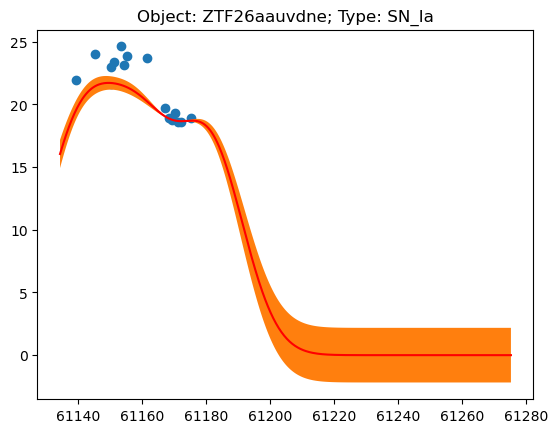

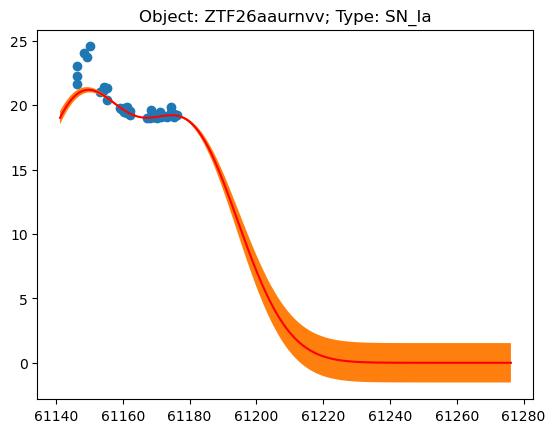

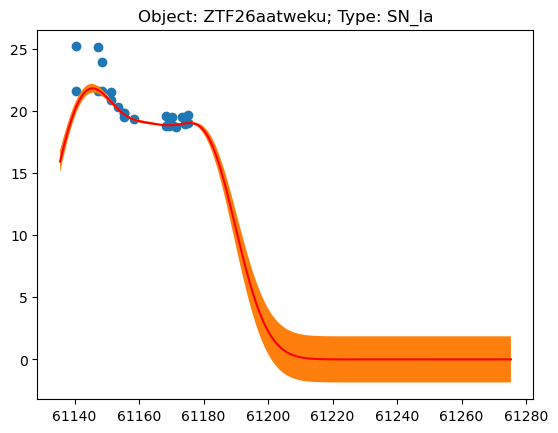

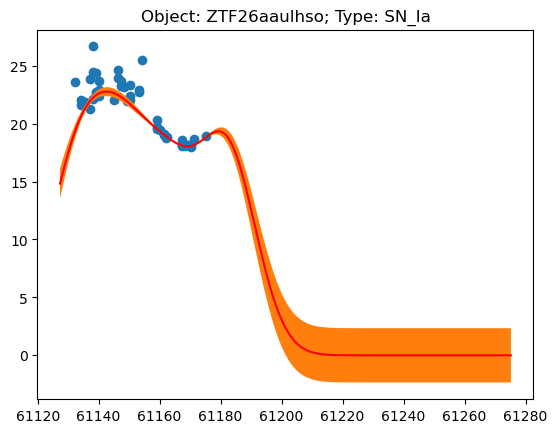

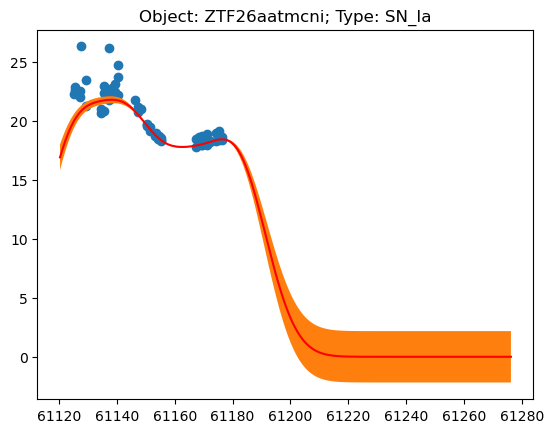

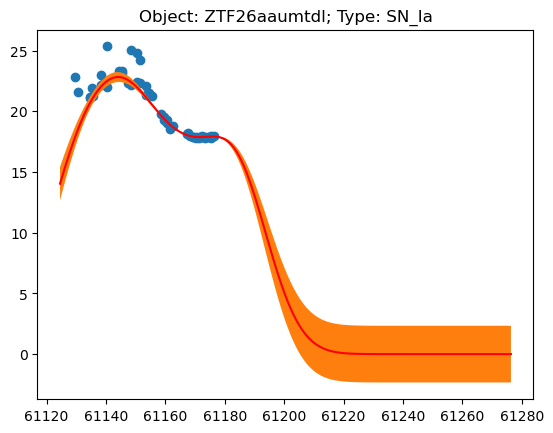

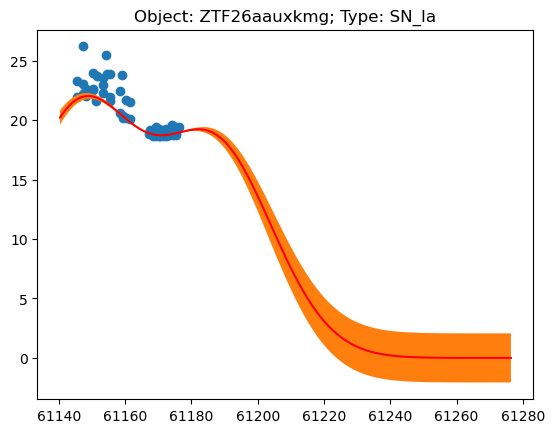

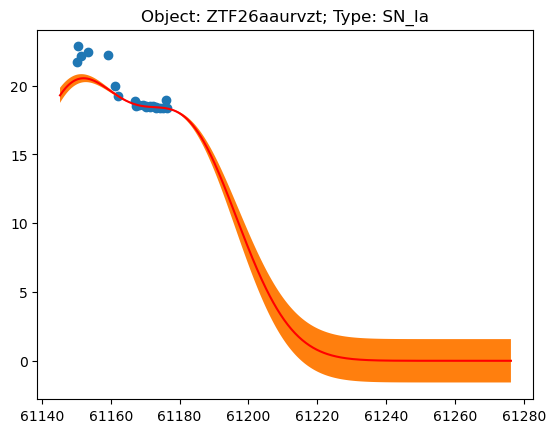

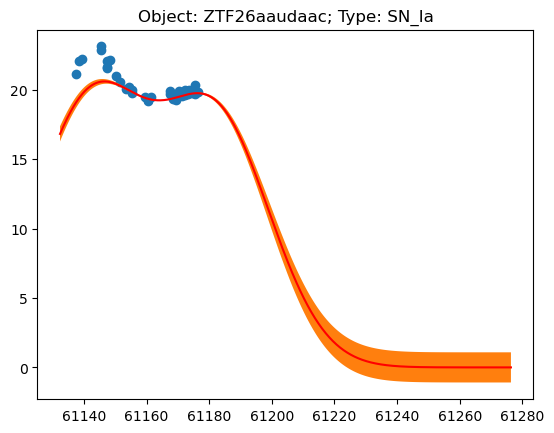

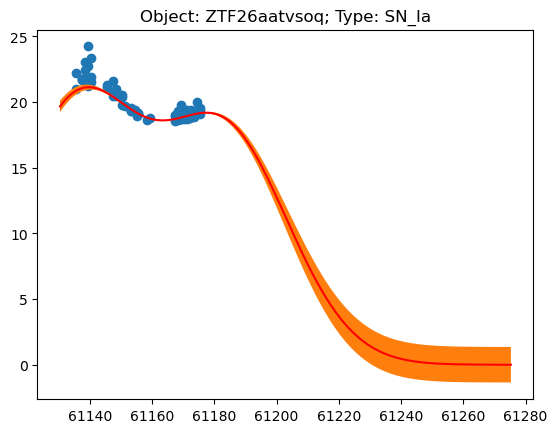

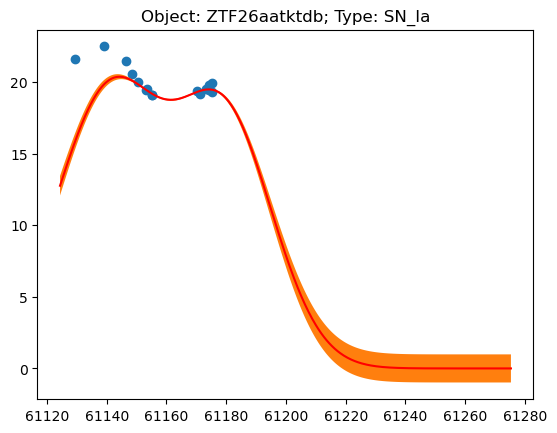

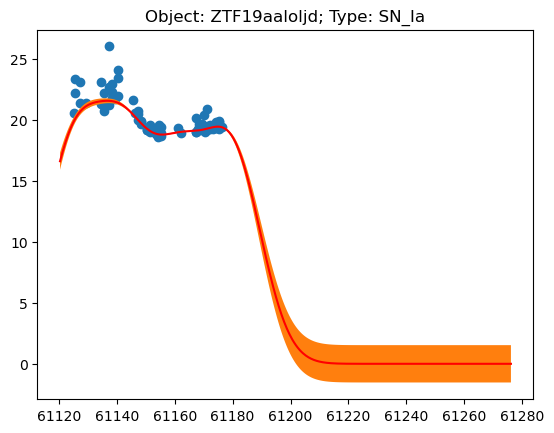

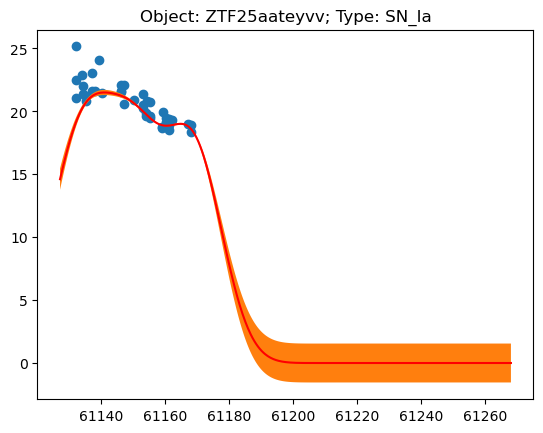

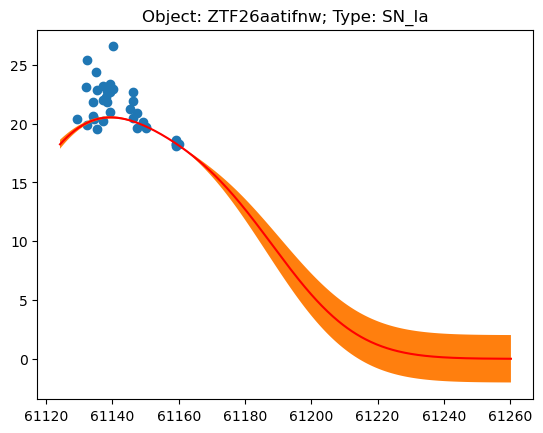

In [12]:
with PdfPages('./SN_Ia_optimized_plots.pdf') as pdf:
    for light in light_curves:
        
        if len(light) > 10:
        
            #initialize data
            time = [obs["mjd"] for obs in light]
            mag = [obs["mag"] for obs in light]
            error = [obs["e_mag"] for obs in light]
            
            #plot raw lightcurve
            plt.scatter(time, mag, marker='o')
            
            #initialize data range
            x_fit = np.linspace(np.min(time) - 5, np.max(time) + 100, 500)
    
            sampler = emcee.EnsembleSampler(n_walkers, n_params, log_posterior, args=[time, mag, error])  # complete
    
            # run!
            empty = sampler.run_mcmc(initial_guesses.T, n_steps)
    
            flat = sampler.get_chain(discard=50, flat=True)
            
            #get george off
            kernel =  np.var(mag) * george.kernels.ExpSquaredKernel(np.median(flat))
            gp = george.GP(kernel)
                
            #use george
            gp.compute(time, error)
            pred, pred_var = gp.predict(mag, x_fit, return_var=True)
            
            #plot george
            plt.plot(x_fit, pred, color='r')
            error = np.pow(pred_var, 0.5)
            
            plt.fill_between(x_fit, pred - error, pred + error, interpolate=True)
            plt.title(f"Object: {light[0]["oid"]}; Type: SN_Ia")
    
            pdf.savefig()
            plt.show()
            plt.close()